In [1]:
import sys

sys.path.append("../..")

In [2]:
# import os
# os.environ['PROJ_LIB'] = '/opt/anaconda3/envs/claymodel/share/proj'

# explicitly set the PROJ data directory to ensure pyproj can resolve EPSG codes correctly.
from pyproj.datadir import set_data_dir

set_data_dir("/opt/anaconda3/envs/claymodel/share/proj")

In [3]:
import pystac_client 
import pandas as pd
import planetary_computer
import stackstac
import rasterio
from rasterio.windows import Window
from rasterio.transform import xy
from rasterio.warp import transform
import numpy as np
from pathlib import Path
from datetime import datetime
from tqdm import tqdm
from pyproj import Transformer
from rasterio.errors import RasterioIOError
from rasterio._err import CPLE_AppDefinedError, CPLE_OpenFailedError



In [4]:
CLAY_TO_S2 = {
    "blue":      "B02",
    "green":     "B03",
    "red":       "B04",
    "nir":       "B08",
}


In [5]:
def normalize_latlon(lat, lon):
    lat_norm = (lat + 90.0) / 180.0
    lon_norm = (lon + 180.0) / 360.0
    return lat_norm, lon_norm


def normalize_time(dt: datetime):
    week = dt.isocalendar().week / 52.0
    hour = dt.hour / 24.0
    return week, hour


In [6]:
STAC_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"
COLLECTION = "sentinel-2-l2a"

BBOX = [77.95, 30.20, 78.20, 30.45]   # example (Dehradun)
DATE_RANGE = "2024-01-01/2025-01-15"

CHIP_SIZE = 64        # Sentinel-2 friendly
BATCH_SIZE = 128
MAX_ITEMS = 5

BASE_DIR = Path("./data_s2")
BASE_DIR.mkdir(exist_ok=True, parents=True)


In [9]:
catalog = pystac_client.Client.open(STAC_URL, modifier=planetary_computer.sign_inplace)

search = catalog.search(
    collections=[COLLECTION],
    bbox=BBOX,
    datetime=DATE_RANGE,
    query={"eo:cloud_cover": {"lt": 20}},
    max_items=MAX_ITEMS,
)

items = list(search.get_items())
print("Scenes found:", len(items))


/opt/anaconda3/envs/odcenv/lib/python3.11/site-packages/pystac_client/item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


Scenes found: 5


In [10]:
assets = list(CLAY_TO_S2.values())

cube = stackstac.stack(
    items,
    assets=assets,
    epsg=32644,
    resolution=10,
    bounds_latlon=BBOX,
    chunksize=512
)


# Rename bands to Clay names
cube = cube.assign_coords(band=list(CLAY_TO_S2.keys()))

# Reflectance scaling
cube = cube.where(cube > 0) / 10000


In [11]:
transformer = Transformer.from_crs(
    32644, 4326, always_xy=True
)  # UTM zone 44N to WGS84

In [12]:
chips = []
latlon_list = []
time_list = []

for t_idx in tqdm(range(len(cube.time)), desc="Processing timesteps"):

    dt = pd.to_datetime(cube.time.values[t_idx]).to_pydatetime()
    week_norm, hour_norm = normalize_time(dt)

    img = cube.isel(time=t_idx).values   # (4, H, W)
    _, H, W = img.shape

    for i in range(0, H - CHIP_SIZE, CHIP_SIZE):
        for j in range(0, W - CHIP_SIZE, CHIP_SIZE):

            chip = img[:, i:i + CHIP_SIZE, j:j + CHIP_SIZE]

            if chip.shape != (4, CHIP_SIZE, CHIP_SIZE):
                continue

            # chip center in UTM
            y_utm = float(cube.y.values[i + CHIP_SIZE // 2])
            x_utm = float(cube.x.values[j + CHIP_SIZE // 2])

            # convert to lat/lon
            lon, lat = transformer.transform(x_utm, y_utm)
            lat_norm, lon_norm = normalize_latlon(lat, lon)

            chips.append(chip)
            latlon_list.append([lat_norm, lon_norm])
            time_list.append([week_norm, hour_norm])

            if len(chips) % 1000 == 0:
                print("Chips so far:", len(chips))


Processing timesteps:  20%|██        | 1/5 [03:21<13:24, 201.23s/it]

Chips so far: 1000


Processing timesteps:  40%|████      | 2/5 [06:25<09:34, 191.42s/it]

Chips so far: 2000
Chips so far: 3000


Processing timesteps:  60%|██████    | 3/5 [08:21<05:13, 156.97s/it]

Chips so far: 4000
Chips so far: 5000


Processing timesteps:  80%|████████  | 4/5 [10:05<02:15, 135.82s/it]

Chips so far: 6000


Processing timesteps: 100%|██████████| 5/5 [13:22<00:00, 160.41s/it]

Chips so far: 7000
Chips so far: 8000


In [13]:
chips

[array([[[0.1374, 0.1431, 0.1488, ..., 0.1528, 0.1438, 0.1314],
         [0.1397, 0.139 , 0.1428, ..., 0.1492, 0.1394, 0.132 ],
         [0.139 , 0.1413, 0.1406, ..., 0.145 , 0.136 , 0.1334],
         ...,
         [0.1311, 0.1289, 0.1314, ..., 0.1352, 0.1327, 0.1323],
         [0.1368, 0.1331, 0.1296, ..., 0.1349, 0.1335, 0.1322],
         [0.1395, 0.1298, 0.1284, ..., 0.1324, 0.1272, 0.1276]],
 
        [[0.1565, 0.1568, 0.165 , ..., 0.1716, 0.1581, 0.1442],
         [0.1532, 0.1488, 0.1606, ..., 0.1652, 0.1524, 0.145 ],
         [0.1483, 0.1568, 0.159 , ..., 0.1591, 0.1494, 0.1448],
         ...,
         [0.1431, 0.1403, 0.1405, ..., 0.1494, 0.1418, 0.1407],
         [0.153 , 0.1408, 0.1393, ..., 0.1497, 0.1458, 0.1496],
         [0.155 , 0.1397, 0.1356, ..., 0.1393, 0.1328, 0.1349]],
 
        [[0.1497, 0.1558, 0.1704, ..., 0.1882, 0.1714, 0.1537],
         [0.15  , 0.1434, 0.1562, ..., 0.181 , 0.159 , 0.1548],
         [0.1405, 0.1516, 0.1498, ..., 0.1735, 0.1556, 0.1528],
      

In [15]:
BATCH_SIZE = 128
OUT_DIR = Path("./cubes_10m")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [16]:
print("Total chips:", len(chips))
print("Channels per chip:", chips[0].shape[0])
print("Chip shape:", chips[0].shape)


Total chips: 8360
Channels per chip: 4
Chip shape: (4, 64, 64)


In [17]:
num_cubes = len(chips) // BATCH_SIZE
print("Total full cubes:", num_cubes)

for cube_idx in range(num_cubes):

    start = cube_idx * BATCH_SIZE
    end = start + BATCH_SIZE

    cube_pixels = np.stack(chips[start:end])          # (128, 4, 64, 64)
    cube_latlon = np.array(latlon_list[start:end])    # (128, 2)
    cube_time   = np.array(time_list[start:end])      # (128, 2)

    np.savez_compressed(
        OUT_DIR / f"cube_{cube_idx}.npz",
        pixels=cube_pixels,
        latlon_norm=cube_latlon,
        time_norm=cube_time,
    )

    print(f"✅ Saved cube_{cube_idx}.npz")


Total full cubes: 65
✅ Saved cube_0.npz
✅ Saved cube_1.npz
✅ Saved cube_2.npz
✅ Saved cube_3.npz
✅ Saved cube_4.npz
✅ Saved cube_5.npz
✅ Saved cube_6.npz
✅ Saved cube_7.npz
✅ Saved cube_8.npz
✅ Saved cube_9.npz
✅ Saved cube_10.npz
✅ Saved cube_11.npz
✅ Saved cube_12.npz
✅ Saved cube_13.npz
✅ Saved cube_14.npz
✅ Saved cube_15.npz
✅ Saved cube_16.npz
✅ Saved cube_17.npz
✅ Saved cube_18.npz
✅ Saved cube_19.npz
✅ Saved cube_20.npz
✅ Saved cube_21.npz
✅ Saved cube_22.npz
✅ Saved cube_23.npz
✅ Saved cube_24.npz
✅ Saved cube_25.npz
✅ Saved cube_26.npz
✅ Saved cube_27.npz
✅ Saved cube_28.npz
✅ Saved cube_29.npz
✅ Saved cube_30.npz
✅ Saved cube_31.npz
✅ Saved cube_32.npz
✅ Saved cube_33.npz
✅ Saved cube_34.npz
✅ Saved cube_35.npz
✅ Saved cube_36.npz
✅ Saved cube_37.npz
✅ Saved cube_38.npz
✅ Saved cube_39.npz
✅ Saved cube_40.npz
✅ Saved cube_41.npz
✅ Saved cube_42.npz
✅ Saved cube_43.npz
✅ Saved cube_44.npz
✅ Saved cube_45.npz
✅ Saved cube_46.npz
✅ Saved cube_47.npz
✅ Saved cube_48.npz
✅ Saved c

In [18]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

In [19]:
#bbox and time


bbox = [77.95, 30.20, 78.20, 30.45]

time = "2024-01-01/2026-01-15"

In [20]:
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=time,
    query={
        "eo:cloud_cover": {"lt": 20}
    }
)

items = list(search.get_items())
print(f"Scenes found: {len(items)}")


/opt/anaconda3/envs/odcenv/lib/python3.11/site-packages/pystac_client/item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


Scenes found: 166


In [21]:
item = items[0]

print(item.datetime)
print(item.properties.get("proj:epsg"))
print(item.bbox)


2026-01-08 05:31:09.024000+00:00
None
[77.8679825, 29.7058729, 79.0187982, 30.7178664]


In [22]:
assets = list(CLAY_TO_S2.values())

In [23]:
assets

['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12']

In [24]:
cube = stackstac.stack(
    items,
    assets=assets,
    epsg=4326,
    resolution=10,
    bounds_latlon=bbox,
    chunksize=2048)

In [18]:
import numpy as np

cube_path = "./cubes_10m/cube_0.npz"  # adjust if needed
data = np.load(cube_path)

print("Keys in cube:", data.files)


Keys in cube: ['pixels', 'latlon_norm', 'time_norm']


In [19]:
pixels = data["pixels"]
latlon = data["latlon_norm"]
time   = data["time_norm"]

print("pixels shape:", pixels.shape)
print("latlon_norm shape:", latlon.shape)
print("time_norm shape:", time.shape)


pixels shape: (128, 4, 64, 64)
latlon_norm shape: (128, 2)
time_norm shape: (128, 2)


In [20]:
band_means = pixels.mean(axis=(0, 2, 3))
print("Mean per band:", band_means)


Mean per band: [0.13763276 0.15055267 0.14888722 0.30856734]


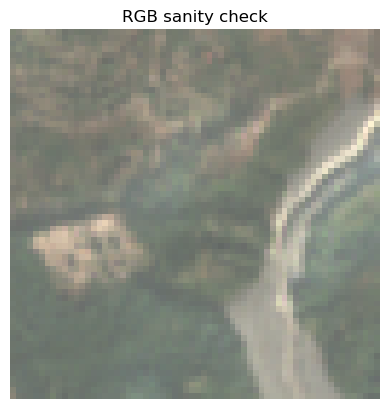

In [21]:
import matplotlib.pyplot as plt

chip = pixels[0]  # first chip

rgb = np.stack([
    chip[2],  # red
    chip[1],  # green
    chip[0],  # blue
], axis=-1)

plt.imshow(rgb / rgb.max())
plt.title("RGB sanity check")
plt.axis("off")
plt.show()
